<a href="https://colab.research.google.com/github/saverin0/bavaria-wheat-sentinel2-oco2/blob/main/notebooks/02_wheat_ndvi_nirv_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Winter wheat NDVI & NIRv per NUTS3 region, Bavaria 2017–2024

## What this notebook does

Extracts **NDVI** (Normalized Difference Vegetation Index) and **NIRv** (Near-Infrared Reflectance of
Vegetation) from monthly Sentinel-2 composites for **winter wheat fields** in Bavaria, Germany, and
aggregates them to NUTS3 (Landkreis) level for March–June of every year 2017–2024.

The outputs shown in this notebook are from the completed full run (5.5 hours on a Colab A100,
High-RAM runtime). Result files are listed in the final cell.

### Why these indices?
- **NDVI** = (NIR − Red) / (NIR + Red). Vegetation greenness; healthy crops typically 0.6–0.9.
- **NIRv** = NDVI × NIR reflectance. Better correlated with photosynthesis / gross primary productivity.

### Key design choices
- **Per-tile processing**: each Sentinel-2 tile (~250 MB) is processed independently. No mosaics, no
  duplicate pixels.
- **Year-specific crop masks**: DLR crop type maps for each year (crop rotation changes every year).
- **GPU acceleration** with CuPy when a GPU is present; falls back to NumPy on CPU.
- **Exact zonal statistics** with `exactextract` (handles partial pixel coverage).
- **Weighted aggregation**: NUTS3 regions spanning several tiles are combined by pixel count.

## Pipeline flow

```
For each year (2017-2024):
  Load year-specific winter wheat mask (croptypes_{year}.tif)
  For each month (March, April, May, June):
    For each Sentinel-2 tile (29 tiles covering Bavaria):
      1. Load B4 (red) and B8 (NIR) from WASP_Cache
      2. Compute NDVI and NIRv (GPU or CPU)
      3. Reproject wheat mask to the tile grid
      4. Keep only winter wheat pixels
      5. exactextract → zonal statistics per NUTS3 region
Final aggregation:
  Weighted mean by pixel count across tiles → one row per year/month/index/NUTS3
  Save Parquet + CSV + plot
```

## Inputs (see README for how to obtain them)

```
{DRIVE_BASE}/
├── WASP_Cache/{year}/{MM_Month}/*_T{tile}_*_B4.tif, *_B8.tif   ← notebook 01
└── Data_CropTypes/croptypes_{year}.tif                          ← DLR crop type maps
```

## Runtime
- Full run: about 5.5 hours on a Colab A100 with High-RAM.
- Set `QUICK_TEST=True` in the configuration cell to process 1 year, 1 month, 2 tiles (a few minutes)
  and check the setup before committing to the full run.



##  SECTION 1: INSTALLATION

Install all required Python packages because these are not included in the default Colab environment.

In [ ]:
# This cell installs all required packages that are not pre-installed in Google Colab.
# The --quiet flag suppresses verbose output to keep the notebook clean.
#
# PACKAGES INSTALLED:
# - rioxarray, xarray: For reading/writing geospatial raster data with xarray interface
# - exactextract: High-performance zonal statistics (handles partial pixel coverage)
# - cupy-cuda12x: GPU-accelerated NumPy for CUDA 12.x (used for fast NDVI/NIRv calculation)
# - polars: Fast DataFrame library (alternative to pandas, better for large data)
# - pyarrow: Required for Parquet file I/O
# - geopandas, shapely: For handling vector geometries (NUTS3 boundaries)
# - tqdm: Progress bars for loops
# - folium, branca: For interactive map visualizations (optional)


import time
cell_start = time.time()  # Track installation time

print("📦 Installing packages...")
print("   This may take 1-2 minutes on first run.")
print()

# Geospatial raster handling
!pip install rioxarray xarray --quiet

# High-performance zonal statistics library
# exactextract properly handles partial pixel coverage using coverage fractions
!pip install exactextract --quiet

# GPU-accelerated array operations (CuPy), only when a GPU is present.
# On CPU runtimes the pipeline falls back to NumPy automatically.
import subprocess
if subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0:
    !pip install cupy-cuda12x --quiet
else:
    print("   No GPU detected: skipping CuPy, NumPy fallback will be used")

# Fast DataFrame library and Parquet support
# Polars is significantly faster than pandas for large datasets
!pip install polars pyarrow --quiet

# Vector geometry handling
!pip install geopandas shapely --quiet

# Progress bars
!pip install tqdm --quiet

# Interactive maps (optional, for visualization)
!pip install folium branca --quiet

print(f"\n✅ Installation complete: {time.time()-cell_start:.1f}s")

📦 Installing packages...
   This may take 1-2 minutes on first run.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.9 MB/s eta 0:00:00

✅ Installation complete: 29.9s


## SECTION 2: IMPORTS & SYSTEM CHECK

Import all required libraries and verify GPU availability.

In [ ]:
# Import all required libraries and check that GPU is available.
# The GPU (CuPy) is used for fast NDVI/NIRv calculation.

import time
cell_start = time.time()

# STANDARD LIBRARY IMPORTS
import os
import gc
import warnings
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass

# NUMERICAL & DATA LIBRARIES
import numpy as np
import polars as pl

# GEOSPATIAL LIBRARIES
import geopandas as gpd
from shapely.geometry import box

# RASTER I/O LIBRARIES
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import tempfile

# GPU LIBRARY (optional, see GPU CHECK below)
try:
    import cupy as cp
except ImportError:
    cp = None

# ZONAL STATISTICS
from exactextract import exact_extract

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# GPU CHECK

try:
    gpu_props = cp.cuda.runtime.getDeviceProperties(0)
    gpu_name = gpu_props['name'].decode()
    gpu_mem = gpu_props['totalGlobalMem'] / 1e9
    GPU_AVAILABLE = True
    print(f"✅ GPU: {gpu_name} ({gpu_mem:.0f} GB)")
except Exception as e:
    GPU_AVAILABLE = False
    print(f"⚠️ No GPU detected, will use CPU (slower): {e}")
    gpu_name = "CPU"

print(f"✅ Imports complete: {time.time()-cell_start:.1f}s")
print(f"   Polars version: {pl.__version__}")
print(f"   NumPy version: {np.__version__}")
print(f"   Rasterio version: {rasterio.__version__}")

✅ GPU: NVIDIA A100-SXM4-80GB (85 GB)
✅ Imports complete: 2.8s
   Polars version: 1.31.0
   NumPy version: 2.0.2
   Rasterio version: 1.4.3



## SECTION 3: MOUNT GOOGLE DRIVE


Mount Google Drive to access input data (WASP_Cache, CropTypes) and save outputs.

In [ ]:
# Input: WASP_Cache (Sentinel-2 tiles) and Data_CropTypes (winter wheat masks)
# Output: Results_PerTile

cell_start = time.time()

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f"\n✅ Drive mounted: {time.time()-cell_start:.1f}s")
    print(f"   Your Drive is accessible at: /content/drive/MyDrive/")
except ImportError:
    print("Not running in Colab: skipping Drive mount. Point DRIVE_BASE at a local folder.")


Mounted at /content/drive

✅ Drive mounted: 22.2s
   Your Drive is accessible at: /content/drive/MyDrive/


## SECTION 4: TIMER UTILITY CLASS

A utility class for tracking execution time of different pipeline stages.

In [ ]:
class Timer:
    """
    Context manager for timing operations.

    This class provides a clean way to time code blocks and collect
    timing statistics across the entire pipeline.

    Class Attributes:
        all_timings (list): Stores all recorded timings as dicts with
                           'operation' (str) and 'seconds' (float) keys

    Instance Attributes:
        name (str): Name of the operation being timed
        verbose (bool): Whether to print timing info (default True)
        start (float): Start timestamp
        elapsed (float): Elapsed time in seconds (set after exit)
    """


    all_timings = []

    def __init__(self, name: str, verbose: bool = True):
        """
        Initialize the timer.

        Args:
            name: Descriptive name for the operation being timed
            verbose: If True, print timing info to stdout
        """
        self.name = name
        self.verbose = verbose

    def __enter__(self):
        """
        Called when entering the 'with' block.
        Records the start time and optionally prints a message.
        """
        self.start = time.time()  #
        if self.verbose:
            print(f"⏱️  {self.name}...", end=" ", flush=True)
        return self

    def __exit__(self, *args):
        """
        Called when exiting the 'with' block.
        Calculates elapsed time and stores the timing.

        Args:
            *args: Exception info (type, value, traceback) - not used here
        """
        self.elapsed = time.time() - self.start


        Timer.all_timings.append({
            'operation': self.name,
            'seconds': self.elapsed
        })

        if self.verbose:
            if self.elapsed < 60:
                print(f"✓ {self.elapsed:.2f}s")
            else:
                print(f"✓ {self.elapsed/60:.2f}min")

    @classmethod
    def summary(cls):
        """
        Print a summary of all recorded timings.

        Creates a formatted table showing:
        - Operation name
        - Time in seconds
        - Percentage of total time
        - Total time

        Returns:
            Polars DataFrame with timing data, or None if no timings recorded
        """
        if not cls.all_timings:
            print("No timings recorded")
            return None

        df = pl.DataFrame(cls.all_timings)
        total = df['seconds'].sum()
        print("\n" + "="*70)
        print("⏱️  TIMING SUMMARY")
        print("="*70)

        for row in df.iter_rows(named=True):
            pct = row['seconds'] / total * 100
            print(f"{row['operation'][:40]:40s} {row['seconds']:8.2f}s ({pct:5.1f}%)")

        print("-"*70)
        print(f"{'TOTAL':40s} {total:8.2f}s ({total/60:.2f} min)")

        return df

    @classmethod
    def reset(cls):
        """
        Reset all recorded timings.
        Call this before starting a new pipeline run.
        """
        cls.all_timings = []

print("✅ Timer class ready")

✅ Timer class ready



## SECTION 5: CONFIGURATION


**This is the main configuration cell.** All paths, years, and parameters are defined here.

In [ ]:
@dataclass
class Config:
    """
    Central configuration class for the pipeline.

    Using a dataclass provides:
    - Clean organization of all parameters
    - Type hints for documentation
    - Default values with __post_init__ for complex initialization

    Attributes:
        YEARS: List of years to process
        DRIVE_BASE: Base path to your Capstone Project folder in Google Drive
        WASP_CACHE: Path to WASP_Cache containing Sentinel-2 tiles
        OUTPUT_BASE: Path where results will be saved
        MONTHS: List of months to process
        SCALE_FACTOR: Divisor to convert DN to reflectance (typically 10000)
        WINTER_WHEAT_CODE: Value in croptypes raster representing winter wheat
        NODATA_VALUE: Value to use for invalid/masked pixels
        BAVARIA_PREFIXES: NUTS3 ID prefixes for Bavarian regions
    """

    YEARS: List[int] = None


    # Project folder. Override with the WHEAT_DRIVE_BASE environment variable when running locally.
    DRIVE_BASE: Path = Path(os.environ.get('WHEAT_DRIVE_BASE', '/content/drive/MyDrive/Capstone Project'))

    # Smoke test: True → first year, first month, MAX_TILES_PER_MONTH tiles only.
    QUICK_TEST: bool = False
    MAX_TILES_PER_MONTH: Optional[int] = None

    # ========== INPUT PATHS ==========
    # WASP_Cache structure: {WASP_CACHE}/{YEAR}/{MM_Month}/SENTINEL2A_*_T{TILE}_C_B{4|8}.tif
    # Example: WASP_Cache/2017/03_March/SENTINEL2A_20170315-000000-000_L3A_T32UMU_C_B4.tif
    WASP_CACHE: Path = None
    CROPTYPES_PATH_TEMPLATE: str = 'Data_CropTypes/croptypes_{year}.tif'
    OUTPUT_BASE: Path = None
    MONTHS: List[str] = None
    SCALE_FACTOR: int = 10000
    WINTER_WHEAT_CODE: int = 11
    NODATA_VALUE: float = -9999.0
    BAVARIA_PREFIXES: List[str] = None

    def __post_init__(self):
        """
        Initialize default values after dataclass creation.
        This method is called automatically after __init__.
        """

        if self.YEARS is None:
            self.YEARS = list(range(2017, 2025))  # [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
            # For testing with a single year, use:
            # self.YEARS = [2017]

        if self.MONTHS is None:
            self.MONTHS = ['March', 'April', 'May', 'June']

        if self.QUICK_TEST:
            self.YEARS = self.YEARS[:1]
            self.MONTHS = self.MONTHS[:1]
            self.MAX_TILES_PER_MONTH = self.MAX_TILES_PER_MONTH or 2

        if self.WASP_CACHE is None:
            self.WASP_CACHE = self.DRIVE_BASE / 'WASP_Cache'

        if self.OUTPUT_BASE is None:
            self.OUTPUT_BASE = self.DRIVE_BASE / 'Results_PerTile'

        self.OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

        if self.MONTHS is None:
            self.MONTHS = ['March', 'April', 'May', 'June']

        if self.BAVARIA_PREFIXES is None:
            # DE21 = Oberbayern (Upper Bavaria)
            # DE22 = Niederbayern (Lower Bavaria)
            # DE23 = Oberpfalz (Upper Palatinate)
            # DE24 = Oberfranken (Upper Franconia)
            # DE25 = Mittelfranken (Middle Franconia)
            # DE26 = Unterfranken (Lower Franconia)
            # DE27 = Schwaben (Swabia)
            self.BAVARIA_PREFIXES = ['DE21', 'DE22', 'DE23', 'DE24', 'DE25', 'DE26', 'DE27']


    def get_croptypes_path(self, year: int) -> Path:
        """
        Get the path to the crop types raster for a specific year.

        Each year has its own crop classification file because:
        - Crop rotations change fields from wheat to other crops
        - Classification accuracy varies by year
        - Some fields may be fallow in certain years

        Args:
            year: The year (e.g., 2017)

        Returns:
            Path to the croptypes_{year}.tif file
        """
        return self.DRIVE_BASE / self.CROPTYPES_PATH_TEMPLATE.format(year=year)


config = Config(QUICK_TEST=False)   # set QUICK_TEST=True for a few-minute smoke test

print("📁 Configuration:")
print(f"   Years to process: {config.YEARS}")
print(f"   Number of years: {len(config.YEARS)}")
print(f"   Months: {config.MONTHS}")
print(f"   WASP Cache: {config.WASP_CACHE}")
print(f"   Output: {config.OUTPUT_BASE}")
print(f"   Winter wheat code: {config.WINTER_WHEAT_CODE}")
print(f"   Scale factor: {config.SCALE_FACTOR}")
print(f"   NoData value: {config.NODATA_VALUE}")
if config.QUICK_TEST:
    print(f"   QUICK TEST: max {config.MAX_TILES_PER_MONTH} tiles per month")
if not config.WASP_CACHE.exists():
    print(f"\n⚠️ WASP cache not found at {config.WASP_CACHE} - run notebook 01 or fix DRIVE_BASE")

config.OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
print("\n✅ Configuration complete")
print(f"   Estimated runtime: ~{len(config.YEARS) * 30}-{len(config.YEARS) * 40} minutes total")

📁 Configuration:
   Years to process: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
   Number of years: 8
   Months: ['March', 'April', 'May', 'June']
   Bavaria tiles: 14 tiles
   WASP Cache: /content/drive/MyDrive/Capstone Project/WASP_Cache
   Output: /content/drive/MyDrive/Capstone Project/Results_PerTile
   Winter wheat code: 11
   Scale factor: 10000
   NoData value: -9999.0

✅ Configuration complete
   Estimated runtime: ~240-320 minutes total


## SECTION 6: DIAGNOSTIC - CHECK DATA PROPERTIES

Before processing, we check the actual data properties (nodata value, scale factor) from a sample tile.

In [ ]:
def diagnose_tile_properties(wasp_cache: Path, year: int = 2017) -> Optional[Dict]:
    """
    Check nodata value and scale factor from actual tile files.

    This function reads a sample tile and extracts metadata to ensure
    our configuration matches the actual data properties.

    Args:
        wasp_cache: Path to the WASP_Cache directory
        year: Year to check (default 2017, using first available year)

    Returns:
        Dictionary with 'nodata', 'scale_factor', and 'dtype' keys,
        or None if no files found
    """
    print("🔍 DIAGNOSING TILE PROPERTIES")
    print("=" * 50)

    year_path = wasp_cache / str(year)
    sample_file = None

    for month_folder in ['03_March', '04_April', '05_May', '06_June']:
        month_path = year_path / month_folder
        if month_path.exists():
            tifs = list(month_path.glob('*B4*.tif'))
            if tifs:
                sample_file = tifs[0]
                break

    if not sample_file:
        print(f"❌ No tile files found in {year_path}!")
        print("   Please check that WASP_Cache path is correct.")
        return None

    print(f"📄 Sample file: {sample_file.name}")
    print()

    with rasterio.open(sample_file) as src:
        print(f"   CRS: {src.crs}")
        print(f"   Shape: {src.shape}")
        print(f"   Dtype: {src.dtypes[0]}")
        print(f"   Nodata (metadata): {src.nodata}")
        print()

        data = src.read(1)
        if src.nodata is not None:
            valid_data = data[data != src.nodata]
        else:
            valid_data = data[data != 0]

        print(f"   Value statistics:")
        print(f"      Min: {valid_data.min()}")
        print(f"      Max: {valid_data.max()}")
        print(f"      Mean: {valid_data.mean():.2f}")
        print()

        if valid_data.max() > 1:
            if valid_data.max() > 10000:
                print("   ⚠️  Values > 10000 - unusual, please check")
                scale = 10000
            elif valid_data.max() > 1000:
                print("   📊 Scale factor needed: divide by 10000")
                scale = 10000
            else:
                print("   📊 Scale factor needed: divide by 1000")
                scale = 1000
        else:
            print("   ✓ Values already 0-1, no scaling needed")
            scale = 1

        nodata = src.nodata
        if nodata is None:
            zero_pct = (data == 0).sum() / data.size * 100
            if zero_pct > 5:
                print(f"   📊 No nodata in metadata, but {zero_pct:.1f}% zeros - likely nodata=0")
                nodata = 0
            else:
                print("   ⚠️  No nodata value detected")
                nodata = 0
        else:
            print(f"   ✓ Nodata value: {nodata}")

        return {
            'nodata': nodata,
            'scale_factor': scale,
            'dtype': src.dtypes[0]
        }

tile_props = diagnose_tile_properties(config.WASP_CACHE, config.YEARS[0])

if tile_props:
    print("\n" + "=" * 50)
    print("📋 CONFIGURATION UPDATE:")
    print(f"   config.NODATA_VALUE = {tile_props['nodata']}")
    print(f"   config.SCALE_FACTOR = {tile_props['scale_factor']}")


    config.NODATA_VALUE = tile_props['nodata'] if tile_props['nodata'] is not None else 0
    config.SCALE_FACTOR = tile_props['scale_factor']
    print("\n   ✓ Config auto-updated!")
else:
    print("\n⚠️  Could not diagnose tile properties. Using default config values.")

🔍 DIAGNOSING TILE PROPERTIES
📄 Sample file: SENTINEL2A_20170315-000000-000_L3A_T33UUS_C_B4.tif

   CRS: EPSG:32633
   Shape: (10980, 10980)
   Dtype: int16
   Nodata (metadata): -10000.0

   Value statistics:
      Min: 0
      Max: 15539
      Mean: 676.49

   ⚠️  Values > 10000 - unusual, please check
   ✓ Nodata value: -10000.0

📋 CONFIGURATION UPDATE:
   config.NODATA_VALUE = -10000.0
   config.SCALE_FACTOR = 10000

   ✓ Config auto-updated!


##  SECTION 7: DISCOVER TILE STRUCTURE
Scan the WASP_Cache directory to discover available tiles and their organization.

In [ ]:
import re

def parse_tile_filename(filename: str) -> Dict:
    """
    Parse Sentinel-2 tile filename to extract metadata.

    Example filename: SENTINEL2A_20170315-000000-000_L3A_T32UMU_C_B4.tif

    The filename contains:
    - SENTINEL2A: Satellite name (2A or 2B)
    - 20170315: Date (YYYYMMDD)
    - -000000-000: Time/processing info
    - L3A: Processing level
    - T32UMU: MGRS tile ID
    - C: Some processing flag
    - B4: Band number

    Args:
        filename: The filename to parse

    Returns:
        Dictionary with 'tile_id', 'band', and 'date' keys
    """
    # Extract tile ID: Look for _T followed by 2 digits and 3 letters, then _
    # Pattern: _(T\d{2}[A-Z]{3})_
    # Example: _T32UMU_ -> T32UMU
    tile_match = re.search(r'_(T\d{2}[A-Z]{3})_', filename)

    # Extract band: Look for _B followed by digits at end of filename
    # Pattern: _B(\d+)\.tif$
    # Example: _B4.tif -> B4
    band_match = re.search(r'_B(\d+)\.tif$', filename)

    # Extract date: Look for 8 digits followed by -
    # Pattern: _(\d{8})-
    # Example: _20170315- -> 20170315
    date_match = re.search(r'_(\d{8})-', filename)

    return {
        'tile_id': tile_match.group(1) if tile_match else None,
        'band': f'B{band_match.group(1)}' if band_match else None,
        'date': date_match.group(1) if date_match else None
    }


def discover_tile_structure(wasp_cache: Path, year: int) -> Optional[Dict]:
    """
    Discover tile organization in WASP_Cache for a given year.

    This function scans the directory structure to find:
    - Which tiles are available
    - Which months have data
    - Which tiles have complete B4+B8 pairs

    Args:
        wasp_cache: Path to WASP_Cache directory
        year: Year to scan

    Returns:
        Dictionary with structure information, or None if path not found
    """
    year_path = wasp_cache / str(year)

    if not year_path.exists():
        print(f"⚠️ Year path not found: {year_path}")
        return None

    print(f"\n📂 Scanning: {year_path}")
    print("─" * 50)

    structure = {
        'year': year,
        'base_path': year_path,
        'months': {},
        'all_tiles': set(),  # Set of all unique tile IDs
        'structure_type': None
    }

    month_folders = {
        '03_March': 'March',
        '04_April': 'April',
        '05_May': 'May',
        '06_June': 'June'
    }

    for folder_name, month_name in month_folders.items():
        month_path = year_path / folder_name

        if not month_path.exists():
            continue

        tif_files = list(month_path.glob('*.tif'))

        tiles_in_month = {}

        for f in tif_files:
            parsed = parse_tile_filename(f.name)

            if parsed['tile_id'] and parsed['band']:
                tile_id = parsed['tile_id']

                if tile_id not in tiles_in_month:
                    tiles_in_month[tile_id] = {'B4': None, 'B8': None}

                tiles_in_month[tile_id][parsed['band']] = f

                structure['all_tiles'].add(tile_id)

        structure['months'][month_name] = {
            'folder': folder_name,
            'path': month_path,
            'tiles': tiles_in_month,
            'n_complete': sum(1 for t in tiles_in_month.values() if t['B4'] and t['B8'])
        }

    structure['structure_type'] = 'tiles_by_month'
    structure['all_tiles'] = sorted(structure['all_tiles'])

    print(f"   Structure: tiles organized by month")
    print(f"   Total unique tiles: {len(structure['all_tiles'])}")
    print(f"\n   Tiles per month:")
    for month, data in structure['months'].items():
        print(f"      {month}: {data['n_complete']} complete tile pairs (B4+B8)")

    return structure

tile_structure = discover_tile_structure(config.WASP_CACHE, config.YEARS[0])

if tile_structure:
    print(f"\n📊 Found {len(tile_structure['all_tiles'])} tiles:")
    zone32 = [t for t in tile_structure['all_tiles'] if t.startswith('T32')]
    zone33 = [t for t in tile_structure['all_tiles'] if t.startswith('T33')]

    print(f"   UTM Zone 32N: {len(zone32)} tiles - {zone32[:5]}...")
    if zone33:
        print(f"   UTM Zone 33N: {len(zone33)} tiles - {zone33[:5]}...")
    else:
        print(f"   UTM Zone 33N: 0 tiles")


📂 Scanning: /content/drive/MyDrive/Capstone Project/WASP_Cache/2017
──────────────────────────────────────────────────
   Structure: tiles organized by month
   Total unique tiles: 29

   Tiles per month:
      March: 29 complete tile pairs (B4+B8)
      April: 29 complete tile pairs (B4+B8)
      May: 29 complete tile pairs (B4+B8)
      June: 29 complete tile pairs (B4+B8)

📊 Found 29 tiles:
   UTM Zone 32N: 20 tiles - ['T32TMT', 'T32TNT', 'T32TPT', 'T32TQT', 'T32UMA']...
   UTM Zone 33N: 9 tiles - ['T33TUN', 'T33UUP', 'T33UUQ', 'T33UUR', 'T33UUS']...


## SECTION 8: LOAD NUTS3 REGIONS

Load the NUTS3 administrative boundaries for Bavaria from the EU's GISCO service.

In [ ]:
pipeline_start = time.time()  # Start tracking total pipeline time

with Timer("Load NUTS3 regions"):

    nuts_url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson"
    nuts_all = gpd.read_file(nuts_url)
    nuts3 = nuts_all[nuts_all['NUTS_ID'].str[:4].isin(config.BAVARIA_PREFIXES)].copy()
    nuts3_wgs = nuts3.copy()

# Print summary
print(f"   Loaded {len(nuts3)} NUTS3 regions")
print(f"   Columns: {list(nuts3.columns)}")
print(f"\n   Sample NUTS3 IDs: {nuts3['NUTS_ID'].head().tolist()}")
print(f"   Sample names: {nuts3['NUTS_NAME'].head().tolist()}")

⏱️  Load NUTS3 regions... ✓ 11.13s
   Loaded 96 NUTS3 regions
   Columns: ['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry']

   Sample NUTS3 IDs: ['DE226', 'DE219', 'DE249', 'DE21A', 'DE21B']
   Sample names: ['Kelheim', 'Eichstätt', 'Hof, Landkreis', 'Erding', 'Freising']



## SECTION 9: TILE-NUTS3 INTERSECTION FUNCTIONS


Functions to find which NUTS3 regions intersect with each Sentinel-2 tile.

In [ ]:
def find_intersecting_nuts3(raster_path: Path, nuts3_gdf: gpd.GeoDataFrame) -> Tuple[gpd.GeoDataFrame, any]:
    """
    Find NUTS3 regions that intersect with a raster tile.

    This function:
    1. Opens the raster to get its bounds and CRS
    2. Creates a bounding box polygon from the raster extent
    3. Reprojects NUTS3 boundaries to the raster's CRS
    4. Finds all NUTS3 regions that intersect the bounding box

    Args:
        raster_path: Path to the raster file (GeoTIFF)
        nuts3_gdf: GeoDataFrame with NUTS3 boundaries in WGS84

    Returns:
        Tuple of:
        - GeoDataFrame: NUTS3 regions intersecting the tile (in tile CRS)
        - CRS: The raster's coordinate reference system
    """
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        raster_crs = src.crs
        bbox = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
        bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs=raster_crs)
        nuts3_proj = nuts3_gdf.to_crs(raster_crs)
        intersecting = nuts3_proj[nuts3_proj.intersects(bbox)].copy()

    return intersecting, raster_crs


print("✅ Intersection functions ready")

✅ Intersection functions ready


## SECTION 10: WHEAT MASK HANDLER

Class to handle loading and reprojecting wheat masks for different tile CRS.

In [ ]:
# This class handles the winter wheat crop mask.
# The DLR (German Aerospace Center) provides yearly crop classification maps
# for Germany. These maps classify each pixel by crop type.
#
# The challenge is that:
#   1. The crop type raster is in a different CRS than Sentinel-2 tiles
#   2. Each Sentinel-2 tile may have a different CRS (UTM 32N or 33N)
#   3. Reprojecting the full mask for each tile is slow
#
# Solution: This class caches reprojected masks to avoid repeated computation.

class WheatMaskHandler:
    """
    Handles wheat mask loading and reprojection to different tile CRS.

    This class provides efficient access to year-specific wheat masks
    by caching reprojected versions for each unique tile grid.

    Attributes:
        croptypes_path (Path): Path to the crop types GeoTIFF
        wheat_code (int): Value in croptypes raster for winter wheat (default 11)
        cache (dict): Cache of reprojected masks keyed by tile properties
        original_crs: CRS of the original croptypes raster
        original_transform: Affine transform of original raster
        original_shape: (rows, cols) of original raster
        original_bounds: BoundingBox of original raster
    """

    def __init__(self, croptypes_path: Path, wheat_code: int = 11):
        """
        Initialize the wheat mask handler.

        Loads metadata from the croptypes raster without loading the full data.

        Args:
            croptypes_path: Path to croptypes_{year}.tif
            wheat_code: Crop code for winter wheat (DLR uses 11)
        """
        self.croptypes_path = croptypes_path
        self.wheat_code = wheat_code
        self.cache = {}

        with rasterio.open(croptypes_path) as src:
            self.original_crs = src.crs
            self.original_transform = src.transform
            self.original_shape = src.shape
            self.original_bounds = src.bounds

    def get_mask_for_tile(self, tile_path: Path, cache_dir: Path = None) -> Tuple[np.ndarray, dict]:
        """
        Get wheat mask reprojected to match a specific tile's CRS and grid.

        This is the main method called during processing. It:
        1. Reads the tile's metadata (CRS, transform, shape)
        2. Checks if a reprojected mask is already cached
        3. If not cached, loads croptypes, creates binary mask, and reprojects
        4. Returns the mask aligned to the tile's pixel grid

        Args:
            tile_path: Path to the Sentinel-2 tile GeoTIFF
            cache_dir: Optional directory to save cached masks (not used here)

        Returns:
            Tuple of:
            - np.ndarray: Binary mask (1 = wheat, 0 = not wheat) matching tile grid
            - dict: Metadata with 'crs', 'transform', 'shape' keys
        """
        with rasterio.open(tile_path) as tile_src:
            tile_crs = tile_src.crs
            tile_transform = tile_src.transform
            tile_shape = tile_src.shape
            tile_bounds = tile_src.bounds

        cache_key = f"{tile_crs}_{tile_shape}_{tile_bounds}"

        if cache_key in self.cache:
            return self.cache[cache_key]

        with rasterio.open(self.croptypes_path) as src:
            mask_reprojected = np.zeros(tile_shape, dtype=np.uint8)
            croptypes = src.read(1)


            wheat_mask = (croptypes == self.wheat_code).astype(np.uint8)

            reproject(
                source=wheat_mask,
                destination=mask_reprojected,
                src_transform=self.original_transform,
                src_crs=self.original_crs,
                dst_transform=tile_transform,
                dst_crs=tile_crs,
                resampling=Resampling.nearest
            )


        result = (mask_reprojected, {
            'crs': tile_crs,
            'transform': tile_transform,
            'shape': tile_shape
        })
        self.cache[cache_key] = result

        return result

    def clear_cache(self):
        """
        Clear the mask cache and free memory.

        Call this between years to free memory, as each year
        has a different wheat mask (crop rotation).
        """
        self.cache = {}
        gc.collect()  # Force garbage collection


print("✅ WheatMaskHandler ready")

✅ WheatMaskHandler ready


## SECTION 11: VEGETATION INDEX CALCULATOR

NDVI and NIRv for a whole tile at once. Runs on the GPU with CuPy when available, otherwise on the CPU
with NumPy (same code, `xp` is either module).


In [ ]:
def calculate_indices_gpu(b4: np.ndarray, b8: np.ndarray,
                          scale_factor: int = 10000,
                          nodata: float = -9999.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate NDVI and NIRv for one tile, on GPU (CuPy) if available, else CPU (NumPy).

    Args:
        b4: Red band (Band 4) digital numbers
        b8: NIR band (Band 8) digital numbers
        scale_factor: reflectance = DN / scale_factor (WASP uses 10000)
        nodata: value written to invalid pixels (denominator <= 0)

    Returns:
        (ndvi, nirv) as float32 NumPy arrays with the same shape as the input
    """
    xp = cp if GPU_AVAILABLE else np

    b4_x = xp.asarray(b4, dtype=xp.float32) / scale_factor
    b8_x = xp.asarray(b8, dtype=xp.float32) / scale_factor

    denom = b8_x + b4_x
    valid = denom > 0
    safe_denom = xp.where(valid, denom, xp.float32(1.0))   # avoid divide-by-zero warnings on CPU

    ndvi_x = xp.where(valid, (b8_x - b4_x) / safe_denom, xp.float32(nodata))
    ndvi_x = xp.clip(ndvi_x, -1, 1)
    ndvi_x = xp.where(valid, ndvi_x, xp.float32(nodata))
    nirv_x = xp.where(valid, ndvi_x * b8_x, xp.float32(nodata))

    if GPU_AVAILABLE:
        ndvi, nirv = cp.asnumpy(ndvi_x), cp.asnumpy(nirv_x)
        del b4_x, b8_x, denom, valid, safe_denom, ndvi_x, nirv_x
        cp.get_default_memory_pool().free_all_blocks()
        return ndvi, nirv

    return ndvi_x.astype(np.float32), nirv_x.astype(np.float32)


print("✅ GPU calculator ready" if GPU_AVAILABLE else "✅ CPU calculator ready")


✅ GPU calculator ready


## SECTION 12: CORE TILE PROCESSOR

The main function that processes a single Sentinel-2 tile.

In [ ]:
def process_single_tile(
    b4_path: Path,
    b8_path: Path,
    wheat_mask_handler: WheatMaskHandler,
    nuts3_gdf: gpd.GeoDataFrame,
    tile_id: str,
    year: int,
    month: str,
    config: Config
) -> pl.DataFrame:
    """
    Process a single Sentinel-2 tile to extract NDVI/NIRv statistics.

    This function performs the complete processing pipeline for one tile:
    loading data, computing indices, masking, and extracting zonal statistics.

    Args:
        b4_path: Path to Band 4 (Red) GeoTIFF
        b8_path: Path to Band 8 (NIR) GeoTIFF
        wheat_mask_handler: WheatMaskHandler instance for this year
        nuts3_gdf: GeoDataFrame of NUTS3 regions (in WGS84)
        tile_id: The MGRS tile ID (e.g., 'T32UMU')
        year: Year being processed
        month: Month being processed (e.g., 'April')
        config: Configuration object

    Returns:
        Polars DataFrame with columns:
        - year, month, tile_id, index, nuts3_id, region_name
        - mean, std, min, max, pixel_count
    """
    results = []

    try:
        nuts3_intersecting, tile_crs = find_intersecting_nuts3(b4_path, nuts3_gdf)

        if len(nuts3_intersecting) == 0:
            return pl.DataFrame()

        with rasterio.open(b4_path) as src:
            b4 = src.read(1)
            tile_meta = src.meta.copy()
            tile_transform = src.transform

        with rasterio.open(b8_path) as src:
            b8 = src.read(1)

        ndvi, nirv = calculate_indices_gpu(b4, b8, config.SCALE_FACTOR, config.NODATA_VALUE)

        del b4, b8
        wheat_mask, mask_meta = wheat_mask_handler.get_mask_for_tile(b4_path)

        # Apply wheat mask
        ndvi_masked = np.where(wheat_mask == 1, ndvi, config.NODATA_VALUE).astype(np.float32)
        nirv_masked = np.where(wheat_mask == 1, nirv, config.NODATA_VALUE).astype(np.float32)

        # Free memory
        del ndvi, nirv, wheat_mask

        out_meta = tile_meta.copy()
        out_meta.update(
            dtype='float32',
            count=1,
            nodata=config.NODATA_VALUE
        )

        # Process NDVI
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
            tmp_path = tmp.name

        # Write masked NDVI to temp file
        with rasterio.open(tmp_path, 'w', **out_meta) as dst:
            dst.write(ndvi_masked, 1)

        # Run exactextract
        # Statistics requested: mean, stdev, min, max, count
        ndvi_stats = exact_extract(
            tmp_path,
            nuts3_intersecting,
            ['mean', 'stdev', 'min', 'max', 'count'],
            include_cols=['NUTS_ID', 'NUTS_NAME'],
            output='pandas'
        )

        # Clean up temp file
        os.unlink(tmp_path)

        # Process NIRv
        # Same process for NIRv
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
            tmp_path = tmp.name

        with rasterio.open(tmp_path, 'w', **out_meta) as dst:
            dst.write(nirv_masked, 1)

        nirv_stats = exact_extract(
            tmp_path,
            nuts3_intersecting,
            ['mean', 'stdev', 'min', 'max', 'count'],
            include_cols=['NUTS_ID', 'NUTS_NAME'],
            output='pandas'
        )

        os.unlink(tmp_path)

        # Free memory
        del ndvi_masked, nirv_masked

        # Process NDVI results
        for _, row in ndvi_stats.iterrows():
            pixel_count = row.get('count', row.get('count_1', 0))

            # Only include if there are wheat pixels in this region
            if pixel_count > 0:
                results.append({
                    'year': year,
                    'month': month,
                    'tile_id': tile_id,
                    'index': 'NDVI',
                    'nuts3_id': row['NUTS_ID'],
                    'region_name': row['NUTS_NAME'],
                    'mean': row.get('mean', row.get('mean_1', None)),
                    'std': row.get('stdev', row.get('stdev_1', None)),
                    'min': row.get('min', row.get('min_1', None)),
                    'max': row.get('max', row.get('max_1', None)),
                    'pixel_count': pixel_count
                })

        # Process NIRv results
        for _, row in nirv_stats.iterrows():
            pixel_count = row.get('count', row.get('count_1', 0))

            if pixel_count > 0:
                results.append({
                    'year': year,
                    'month': month,
                    'tile_id': tile_id,
                    'index': 'NIRv',
                    'nuts3_id': row['NUTS_ID'],
                    'region_name': row['NUTS_NAME'],
                    'mean': row.get('mean', row.get('mean_1', None)),
                    'std': row.get('stdev', row.get('stdev_1', None)),
                    'min': row.get('min', row.get('min_1', None)),
                    'max': row.get('max', row.get('max_1', None)),
                    'pixel_count': pixel_count
                })

        gc.collect()

    except Exception as e:
        print(f"\n⚠️ Error processing {tile_id}/{month}: {e}")
        return pl.DataFrame()

    return pl.DataFrame(results)


print("✅ Tile processor ready")

✅ Tile processor ready


## SECTION 13: AGGREGATION FUNCTION


Aggregate per-tile statistics to final NUTS3 statistics using weighted means.

In [ ]:
def aggregate_tile_stats(per_tile_stats: pl.DataFrame) -> pl.DataFrame:
    """
    Aggregate per-tile statistics to final NUTS3 statistics.

    Uses weighted mean by pixel count to properly combine statistics
    from NUTS3 regions that span multiple tiles.

    Args:
        per_tile_stats: DataFrame with per-tile statistics
                       Columns: year, month, tile_id, index, nuts3_id,
                               region_name, mean, std, min, max, pixel_count

    Returns:
        Aggregated DataFrame with columns:
        year, month, index, nuts3_id, region_name, mean, std, min, max,
        total_pixels, n_tiles
    """
    if per_tile_stats.is_empty():
        return pl.DataFrame()

    aggregated = (
        per_tile_stats
        .with_columns([
            (pl.col('mean') * pl.col('pixel_count')).alias('weighted_sum'),
            (pl.col('std').pow(2) * pl.col('pixel_count')).alias('var_weighted')
        ])

        .group_by(['year', 'month', 'index', 'nuts3_id', 'region_name'])
        .agg([
            # Sum of weighted means
            pl.col('weighted_sum').sum(),
            pl.col('pixel_count').sum().alias('total_pixels'),
            pl.col('min').min(),
            pl.col('max').max(),
            pl.col('var_weighted').sum(),
            pl.col('tile_id').n_unique().alias('n_tiles')
        ])
        .with_columns([
            (pl.col('weighted_sum') / pl.col('total_pixels')).alias('mean'),
            (pl.col('var_weighted') / pl.col('total_pixels')).sqrt().alias('std')
        ])
        .select([
            'year', 'month', 'index', 'nuts3_id', 'region_name',
            'mean', 'std', 'min', 'max', 'total_pixels', 'n_tiles'
        ])
        .sort(['year', 'month', 'index', 'nuts3_id'])
    )

    return aggregated


print("✅ Aggregation function ready")

✅ Aggregation function ready



## SECTION 14: MAIN PIPELINE FUNCTION


The main orchestrator function that processes all years, months, and tiles.

In [ ]:

# Structure: WASP_Cache/{YEAR}/{MM_Month}/SENTINEL2A_*_T{TILE}_C_B{4|8}.tif

def run_pipeline_tiles_by_month(config: Config, tile_structure: Dict):
    """
    Main pipeline for processing all years and months.

    This function orchestrates the entire processing workflow:
    1. Loop through each year
    2. Load the year-specific wheat mask
    3. Loop through each month
    4. Process each tile
    5. Aggregate results

    Args:
        config: Configuration object with years, months, paths
        tile_structure: Dictionary from discover_tile_structure()

    Returns:
        Tuple of (per_tile_stats, final_stats) as Polars DataFrames
    """
    all_per_tile_stats = []

    for year in config.YEARS:
        print(f"\n{'='*70}")
        print(f"📅 PROCESSING YEAR: {year}")
        print(f"{'='*70}")
        year_structure = discover_tile_structure(config.WASP_CACHE, year)

        if not year_structure:
            print(f"⚠️ No data found for {year}, skipping...")
            continue
        croptypes_path = config.get_croptypes_path(year)

        if not croptypes_path.exists():
            print(f"⚠️ CropTypes not found: {croptypes_path}")
            print(f"   Please ensure croptypes_{year}.tif exists in Data_CropTypes/")
            continue

        with Timer(f"Load wheat mask for {year}"):
            mask_handler = WheatMaskHandler(croptypes_path, config.WINTER_WHEAT_CODE)

        for month in config.MONTHS:
            if month not in year_structure['months']:
                print(f"\n⚠️ {month} not found for {year}")
                continue

            month_data = year_structure['months'][month]
            tiles = month_data['tiles']  # {tile_id: {'B4': path, 'B8': path}}
            if config.MAX_TILES_PER_MONTH:
                tiles = dict(list(tiles.items())[:config.MAX_TILES_PER_MONTH])

            print(f"\n{'─'*50}")
            print(f"📅 {month} {year} - {len(tiles)} tiles")
            print(f"{'─'*50}")

            month_stats = []

            for tile_id, tile_files in tqdm(tiles.items(), desc=f"   {month} tiles"):
                if not tile_files['B4'] or not tile_files['B8']:
                    continue

                b4_path = tile_files['B4']
                b8_path = tile_files['B8']

                tile_stats = process_single_tile(
                    b4_path, b8_path, mask_handler, nuts3_wgs,
                    tile_id, year, month, config
                )

                if not tile_stats.is_empty():
                    month_stats.append(tile_stats)

            if month_stats:
                month_df = pl.concat(month_stats)
                all_per_tile_stats.append(month_df)

                n_tiles = month_df['tile_id'].n_unique()
                n_regions = month_df.filter(pl.col('index') == 'NDVI')['nuts3_id'].n_unique()
                print(f"   ✓ {n_tiles} tiles → {n_regions} NUTS3 regions")

        mask_handler.clear_cache()
        gc.collect()

    if all_per_tile_stats:
        per_tile_stats = pl.concat(all_per_tile_stats)

        print(f"\n{'='*70}")
        print(f" AGGREGATION")
        print(f"{'='*70}")
        print(f"   Total per-tile observations: {len(per_tile_stats)}")

        with Timer("Aggregate tile stats (weighted by pixel count)"):
            final_stats = aggregate_tile_stats(per_tile_stats)

        print(f"   Final NUTS3 observations: {len(final_stats)}")

        # Show how many regions span multiple tiles
        if 'n_tiles' in final_stats.columns:
            multi = final_stats.filter(pl.col('n_tiles') > 1)
            if len(multi) > 0:
                print(f"   NUTS3 regions spanning multiple tiles: {multi['nuts3_id'].n_unique()}")

        return per_tile_stats, final_stats

    return pl.DataFrame(), pl.DataFrame()


print("✅ Pipeline function defined")

✅ Pipeline function defined



## SECTION 15: RUN THE PIPELINE


Execute the pipeline to process all years and months.

In [ ]:
Timer.reset()

pipeline_start = time.time()

if tile_structure and tile_structure['structure_type'] == 'tiles_by_month':
    print("🚀 Running per-tile pipeline for ALL YEARS")
    print(f"   Years to process: {config.YEARS}")
    print(f"   Months per year: {config.MONTHS}")
    print(f"   Tiles per month: ~{len(tile_structure['all_tiles'])}")
    print(f"   Each tile: ~250MB (vs 11GB mosaics)")
    print(f"\n   Estimated total runtime: {len(config.YEARS) * 30}-{len(config.YEARS) * 40} minutes")
    print()

    per_tile_stats, final_stats = run_pipeline_tiles_by_month(config, tile_structure)
else:
    print("⚠️ Tile structure not recognized")
    print(f"   Found structure type: {tile_structure['structure_type'] if tile_structure else 'None'}")
    print("   Please check your WASP_Cache directory structure.")
    print("   Expected: WASP_Cache/{YEAR}/{MM_Month}/*.tif")
    per_tile_stats, final_stats = pl.DataFrame(), pl.DataFrame()

pipeline_elapsed = time.time() - pipeline_start
print(f"\n⏱️ Total pipeline time: {pipeline_elapsed/60:.2f} minutes ({pipeline_elapsed/3600:.2f} hours)")

🚀 Running per-tile pipeline for ALL YEARS
   Years to process: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
   Months per year: ['March', 'April', 'May', 'June']
   Tiles per month: ~29
   Each tile: ~250MB (vs 11GB mosaics)

   Estimated total runtime: 240-320 minutes


📅 PROCESSING YEAR: 2017

📂 Scanning: /content/drive/MyDrive/Capstone Project/WASP_Cache/2017
──────────────────────────────────────────────────
   Structure: tiles organized by month
   Total unique tiles: 29

   Tiles per month:
      March: 29 complete tile pairs (B4+B8)
      April: 29 complete tile pairs (B4+B8)
      May: 29 complete tile pairs (B4+B8)
      June: 29 complete tile pairs (B4+B8)
⏱️  Load wheat mask for 2017... ✓ 1.62s

──────────────────────────────────────────────────
📅 March 2017 - 29 tiles
──────────────────────────────────────────────────


   March tiles:   0%|          | 0/29 [00:00<?, ?it/s]

   ✓ 22 tiles → 95 NUTS3 regions

──────────────────────────────────────────────────
📅 April 2017 - 29 tiles
──────────────────────────────────────────────────


   April tiles:   0%|          | 0/29 [00:00<?, ?it/s]

   ✓ 22 tiles → 95 NUTS3 regions

──────────────────────────────────────────────────
📅 May 2017 - 29 tiles
──────────────────────────────────────────────────


...

   ✓ 22 tiles → 96 NUTS3 regions

──────────────────────────────────────────────────
📅 May 2024 - 29 tiles
──────────────────────────────────────────────────


   May tiles:   0%|          | 0/29 [00:00<?, ?it/s]

   ✓ 22 tiles → 96 NUTS3 regions

──────────────────────────────────────────────────
📅 June 2024 - 29 tiles
──────────────────────────────────────────────────


   June tiles:   0%|          | 0/29 [00:00<?, ?it/s]

   ✓ 22 tiles → 96 NUTS3 regions

📊 AGGREGATION
   Total per-tile observations: 13124
⏱️  Aggregate tile stats (weighted by pixel count)... ✓ 0.32s
   Final NUTS3 observations: 6094
   NUTS3 regions spanning multiple tiles: 65

⏱️ Total pipeline time: 332.66 minutes (5.54 hours)



## SECTION 16: SAVE RESULTS

Save the processed results to Parquet and CSV files.

In [ ]:
if final_stats is not None and not final_stats.is_empty():
    output_dir = config.OUTPUT_BASE

    if len(config.YEARS) == 1:
        year_str = str(config.YEARS[0])
    else:
        year_str = f"{min(config.YEARS)}_{max(config.YEARS)}"
    parquet_path = output_dir / f'{year_str}_nuts3_stats.parquet'
    csv_path = output_dir / f'{year_str}_nuts3_stats.csv'

    with Timer("Save final results"):
        final_stats.write_parquet(parquet_path)
        final_stats.write_csv(csv_path)

        print(f"   Parquet: {parquet_path}")
        print(f"   CSV: {csv_path}")
    if per_tile_stats is not None and not per_tile_stats.is_empty():
        pertile_path = output_dir / f'{year_str}_pertile_stats.parquet'
        per_tile_stats.write_parquet(pertile_path)
        print(f"   Per-tile stats: {pertile_path}")

    print("\n📊 Results Preview (first 10 rows):")
    print(final_stats.head(10))

    print(f"\n📈 Results shape: {final_stats.shape}")
    print(f"   Unique years: {final_stats['year'].unique().to_list()}")
    print(f"   Unique months: {final_stats['month'].unique().to_list()}")
    print(f"   Unique NUTS3 regions: {final_stats['nuts3_id'].n_unique()}")
else:
    print("⚠️ No results to save")

⏱️  Save final results...    Parquet: /content/drive/MyDrive/Capstone Project/Results_PerTile/2017_2024_nuts3_stats.parquet
   CSV: /content/drive/MyDrive/Capstone Project/Results_PerTile/2017_2024_nuts3_stats.csv
✓ 0.12s
   Per-tile stats: /content/drive/MyDrive/Capstone Project/Results_PerTile/2017_2024_pertile_stats.parquet

📊 Results Preview (first 10 rows):
shape: (10, 11)
┌──────┬───────┬───────┬──────────┬───┬───────────┬──────────┬───────────────┬─────────┐
│ year ┆ month ┆ index ┆ nuts3_id ┆ … ┆ min       ┆ max      ┆ total_pixels  ┆ n_tiles │
│ ---  ┆ ---   ┆ ---   ┆ ---      ┆   ┆ ---       ┆ ---      ┆ ---           ┆ ---     │
│ i64  ┆ str   ┆ str   ┆ str      ┆   ┆ f64       ┆ f64      ┆ f64           ┆ u32     │
╞══════╪═══════╪═══════╪══════════╪═══╪═══════════╪══════════╪═══════════════╪═════════╡
│ 2017 ┆ April ┆ NDVI  ┆ DE211    ┆ … ┆ 0.078144  ┆ 0.954907 ┆ 142897.982567 ┆ 2       │
│ 2017 ┆ April ┆ NDVI  ┆ DE212    ┆ … ┆ -0.012895 ┆ 0.983699 ┆ 41112.203067  ┆ 2     


## SECTION 17: SUMMARY STATISTICS
Display summary statistics by year, month, and vegetation index.

In [ ]:
# Calculate and display summary statistics across all processed data.
#
# Shows:
#   - Average NDVI/NIRv per month per year
#   - Variability across regions
#   - Total pixel counts

if final_stats is not None and not final_stats.is_empty():
    print("="*70)
    print("📈 SUMMARY BY YEAR, MONTH, AND INDEX")
    print("="*70)

    # Calculate summary statistics
    summary = (
        final_stats
        .group_by(['year', 'month', 'index'])
        .agg([
            # Average of regional means
            pl.col('mean').mean().alias('avg_mean'),
            # Standard deviation of regional means (variability between regions)
            pl.col('mean').std().alias('std_across_regions'),
            # Total wheat pixels
            pl.col('total_pixels').sum().alias('total_pixels'),
            # Number of regions with data
            pl.col('nuts3_id').n_unique().alias('n_regions')
        ])
        .sort(['year', 'index', 'month'])
    )

    # Print the summary
    print(summary)

    # ===== PRINT PER-YEAR SUMMARY =====
    print("\n" + "="*70)
    print("📊 PER-YEAR SUMMARY")
    print("="*70)

    yearly_summary = (
        final_stats
        .filter(pl.col('index') == 'NDVI')
        .group_by('year')
        .agg([
            pl.col('mean').mean().alias('avg_ndvi'),
            pl.col('total_pixels').sum().alias('total_pixels'),
            pl.col('nuts3_id').n_unique().alias('n_regions')
        ])
        .sort('year')
    )

    for row in yearly_summary.iter_rows(named=True):
        print(f"   {row['year']}: avg NDVI = {row['avg_ndvi']:.3f}, "
              f"{row['total_pixels']/1e6:.1f}M pixels, {row['n_regions']} regions")
else:
    print("No data to summarize")

📈 SUMMARY BY YEAR, MONTH, AND INDEX
shape: (64, 7)
┌──────┬───────┬───────┬──────────┬────────────────────┬──────────────┬───────────┐
│ year ┆ month ┆ index ┆ avg_mean ┆ std_across_regions ┆ total_pixels ┆ n_regions │
│ ---  ┆ ---   ┆ ---   ┆ ---      ┆ ---                ┆ ---          ┆ ---       │
│ i64  ┆ str   ┆ str   ┆ f64      ┆ f64                ┆ f64          ┆ u32       │
╞══════╪═══════╪═══════╪══════════╪════════════════════╪══════════════╪═══════════╡
│ 2017 ┆ April ┆ NDVI  ┆ 0.601054 ┆ 0.085159           ┆ 5.5848e7     ┆ 95        │
│ 2017 ┆ June  ┆ NDVI  ┆ 0.787858 ┆ 0.060103           ┆ 5.5842e7     ┆ 95        │
│ 2017 ┆ March ┆ NDVI  ┆ 0.459331 ┆ 0.068928           ┆ 5.5845e7     ┆ 95        │
│ 2017 ┆ May   ┆ NDVI  ┆ 0.863071 ┆ 0.04611            ┆ 5.5848e7     ┆ 95        │
│ 2017 ┆ April ┆ NIRv  ┆ 0.167746 ┆ 0.036954           ┆ 5.5848e7     ┆ 95        │
│ …    ┆ …     ┆ …     ┆ …        ┆ …                  ┆ …            ┆ …         │
│ 2024 ┆ May   ┆ NDVI  ┆ 


## SECTION 18: TIMING SUMMARY

Display timing information for each operation in the pipeline.

In [ ]:
Timer.summary()


⏱️  TIMING SUMMARY
Load wheat mask for 2017                     1.62s ( 13.4%)
Load wheat mask for 2018                     1.28s ( 10.6%)
Load wheat mask for 2019                     1.36s ( 11.3%)
Load wheat mask for 2020                     1.78s ( 14.8%)
Load wheat mask for 2021                     1.42s ( 11.8%)
Load wheat mask for 2022                     1.51s ( 12.5%)
Load wheat mask for 2023                     1.26s ( 10.5%)
Load wheat mask for 2024                     1.38s ( 11.4%)
Aggregate tile stats (weighted by pixel      0.32s (  2.6%)
Save final results                           0.12s (  1.0%)
----------------------------------------------------------------------
TOTAL                                       12.04s (0.20 min)


operation,seconds
str,f64
"""Load wheat mask for 2017""",1.616991
"""Load wheat mask for 2018""",1.279036
"""Load wheat mask for 2019""",1.361969
"""Load wheat mask for 2020""",1.778368
"""Load wheat mask for 2021""",1.422205
"""Load wheat mask for 2022""",1.505606
"""Load wheat mask for 2023""",1.264189
"""Load wheat mask for 2024""",1.375902
"""Aggregate tile stats (weighted…",0.315876



## SECTION 19: VISUALIZATION


Create a simple visualization of NDVI time series.

Saved: /content/drive/MyDrive/Capstone Project/Results_PerTile/2017_2024_ndvi_timeseries.png


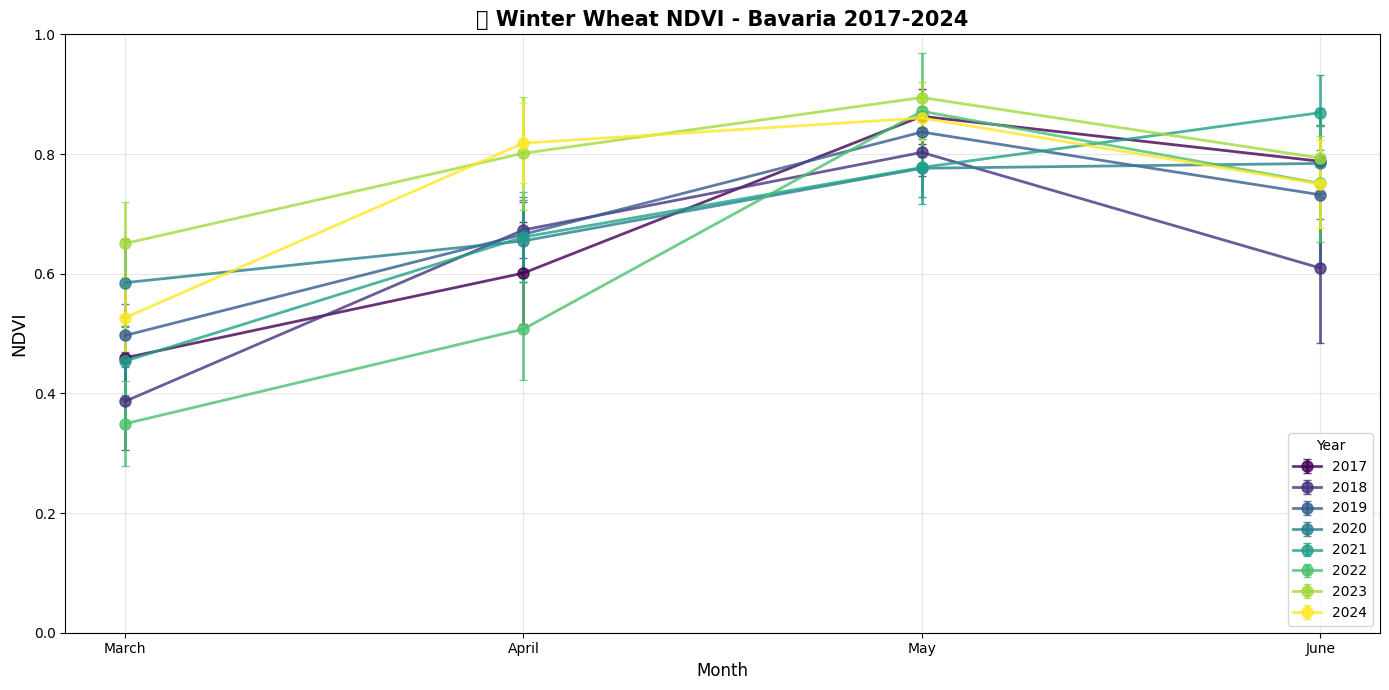

In [ ]:
# Create visualizations of the processed NDVI data.
#
#   - Multi-year comparison plot showing NDVI trends
#   - Saved as PNG file in output directory
# ============================================================

if final_stats is not None and not final_stats.is_empty():
    # Get list of unique years
    years_processed = sorted(final_stats['year'].unique().to_list())

    # Month ordering for x-axis
    month_order = {'March': 3, 'April': 4, 'May': 5, 'June': 6}

    # ===== MULTI-YEAR COMPARISON PLOT =====
    if len(years_processed) > 1:
        fig, ax = plt.subplots(figsize=(14, 7))

        # Color map for different years
        colors = plt.cm.viridis(np.linspace(0, 1, len(years_processed)))

        for i, year in enumerate(years_processed):
            # Filter data for this year and NDVI
            year_data = (
                final_stats
                .filter((pl.col('index') == 'NDVI') & (pl.col('year') == year))
                .group_by('month')
                .agg([
                    pl.col('mean').mean().alias('mean'),
                    pl.col('mean').std().alias('std')
                ])
                .with_columns(pl.col('month').replace(month_order).alias('order'))
                .sort('order')
                .to_pandas()
            )

            # Plot this year's data
            ax.errorbar(
                year_data['month'], year_data['mean'], yerr=year_data['std'],
                fmt='o-', color=colors[i], lw=2, ms=8, capsize=3, capthick=1,
                label=str(year), alpha=0.8
            )

        ax.set_ylabel('NDVI', fontsize=13)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_title(f'🌾 Winter Wheat NDVI - Bavaria {min(years_processed)}-{max(years_processed)}',
                     fontsize=15, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend(title='Year', loc='lower right')

        plt.tight_layout()

        # Save
        fig_path = config.OUTPUT_BASE / f'{min(years_processed)}_{max(years_processed)}_ndvi_timeseries.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_path}")
        plt.show()

    # ===== SINGLE YEAR PLOT =====
    else:
        year = years_processed[0]

        ndvi_monthly = (
            final_stats
            .filter((pl.col('index') == 'NDVI') & (pl.col('year') == year))
            .group_by('month')
            .agg([
                pl.col('mean').mean().alias('mean'),
                pl.col('mean').std().alias('std')
            ])
            .with_columns(pl.col('month').replace(month_order).alias('order'))
            .sort('order')
            .to_pandas()
        )

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.errorbar(
            ndvi_monthly['month'], ndvi_monthly['mean'], yerr=ndvi_monthly['std'],
            fmt='go-', lw=3, ms=12, capsize=5, capthick=2,
            markeredgecolor='black', markeredgewidth=2, ecolor='darkgreen'
        )

        ax.fill_between(
            ndvi_monthly['month'],
            ndvi_monthly['mean'] - ndvi_monthly['std'],
            ndvi_monthly['mean'] + ndvi_monthly['std'],
            alpha=0.2, color='green'
        )

        ax.set_ylabel('NDVI', fontsize=13)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_title(f'🌾 Winter Wheat NDVI - Bavaria {year}', fontsize=15, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        for m, v in zip(ndvi_monthly['month'], ndvi_monthly['mean']):
            ax.annotate(f'{v:.3f}', (m, v), textcoords='offset points',
                        xytext=(0, 15), ha='center', fontsize=11, fontweight='bold')

        plt.tight_layout()

        # Save
        fig_path = config.OUTPUT_BASE / f'{year}_ndvi_timeseries.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_path}")
        plt.show()
else:
    print("No data to visualize")

## SECTION 20: FINAL SUMMARY

Print a complete summary of the processing run.

In [ ]:
# ============================================================
# CELL 20: FINAL SUMMARY
# ============================================================
# Print a comprehensive summary of everything that was processed.
# ============================================================

print("\n" + "="*70)
print("🎉 PIPELINE COMPLETE")
print("="*70)

print(f"\n📅 Years processed: {config.YEARS}")
print(f"   Total years: {len(config.YEARS)}")
print(f"   Months per year: {config.MONTHS}")

if final_stats is not None and not final_stats.is_empty():
    print(f"\n📊 Data Summary:")
    print(f"   NUTS3 regions: {final_stats['nuts3_id'].n_unique()}")
    print(f"   Months: {final_stats['month'].n_unique()}")
    print(f"   Indices: {final_stats['index'].n_unique()} (NDVI, NIRv)")
    print(f"   Total observations: {len(final_stats)}")

    # Calculate total wheat pixels
    total_pixels = final_stats.filter(pl.col('index') == 'NDVI')['total_pixels'].sum()
    print(f"   Total wheat pixels: {total_pixels:,.0f} ({total_pixels/1e9:.2f} billion)")

    # Count multi-tile regions
    if 'n_tiles' in final_stats.columns:
        multi_tile = final_stats.filter(pl.col('n_tiles') > 1)
        print(f"   NUTS3 spanning multiple tiles: {multi_tile['nuts3_id'].n_unique()}")

print(f"\n⏱️ Total time: {pipeline_elapsed/60:.2f} min ({pipeline_elapsed/3600:.2f} hours)")

print(f"\n📁 Output files saved to: {config.OUTPUT_BASE}")
for f in sorted(config.OUTPUT_BASE.glob('*')):
    size = f.stat().st_size / 1e6
    print(f"   {f.name} ({size:.1f} MB)")

print("\n" + "="*70)
print("✅ All processing complete!")
print("="*70)


🎉 PIPELINE COMPLETE

📅 Years processed: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
   Total years: 8
   Months per year: ['March', 'April', 'May', 'June']

📊 Data Summary:
   NUTS3 regions: 96
   Months: 4
   Indices: 2 (NDVI, NIRv)
   Total observations: 6094
   Total wheat pixels: 1,635,388,501 (1.64 billion)
   NUTS3 spanning multiple tiles: 65

⏱️ Total time: 332.66 min (5.54 hours)

📁 Output files saved to: /content/drive/MyDrive/Capstone Project/Results_PerTile
   2017_2024_ndvi_timeseries.png (0.2 MB)
   2017_2024_nuts3_stats.csv (0.8 MB)
   2017_2024_nuts3_stats.parquet (0.2 MB)
   2017_2024_pertile_stats.parquet (0.3 MB)
   2017_ndvi_timeseries_1.png (0.1 MB)
   2017_nuts3_stats_1.csv (0.1 MB)
   2017_nuts3_stats_1.gsheet (0.0 MB)
   2017_nuts3_stats_1.parquet (0.0 MB)
   2017_pertile_stats_1.parquet (0.0 MB)

✅ All processing complete!


## SECTION 21: COLAB RESOURCE SUMMARY

Hardware used for the recorded run (for reporting).

In [ ]:
import psutil

print("=" * 60)
print("📊 GOOGLE COLAB RESOURCE USAGE SUMMARY")
print("=" * 60)

# CPU Info
print("\n🖥️  CPU INFO")
print("-" * 40)
!cat /proc/cpuinfo | grep "model name" | head -1
print(f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"CPU Usage: {psutil.cpu_percent(interval=1)}%")

# RAM Info
print("\n💾 RAM INFO")
print("-" * 40)
ram = psutil.virtual_memory()
print(f"Total:     {ram.total / 1e9:.2f} GB")
print(f"Used:      {ram.used / 1e9:.2f} GB ({ram.percent}%)")
print(f"Available: {ram.available / 1e9:.2f} GB")

# Disk Info
print("\n💿 DISK INFO")
print("-" * 40)
disk = psutil.disk_usage('/')
print(f"Total:     {disk.total / 1e9:.2f} GB")
print(f"Used:      {disk.used / 1e9:.2f} GB ({disk.percent}%)")
print(f"Free:      {disk.free / 1e9:.2f} GB")

# GPU Info (if available)
print("\n🎮 GPU INFO")
print("-" * 40)
try:
    import torch
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Memory Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        print(f"Memory Cached:    {torch.cuda.memory_reserved() / 1e9:.2f} GB")
        !nvidia-smi --query-gpu=memory.total,memory.used,memory.free,utilization.gpu --format=csv
    else:
        print("No GPU available in this runtime")
except ImportError:
    print("PyTorch not installed - checking with nvidia-smi...")
    !nvidia-smi 2>/dev/null || echo "No GPU available"

# Runtime Info
print("\n⏱️  RUNTIME INFO")
print("-" * 40)
import os
print(f"Python PID: {os.getpid()}")
process = psutil.Process(os.getpid())
print(f"Process Memory: {process.memory_info().rss / 1e9:.2f} GB")

print("\n" + "=" * 60)

📊 GOOGLE COLAB RESOURCE USAGE SUMMARY

🖥️  CPU INFO
----------------------------------------
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
CPU Cores: 6 physical, 12 logical
CPU Usage: 0.4%

💾 RAM INFO
----------------------------------------
Total:     179.37 GB
Used:      13.76 GB (8.9%)
Available: 163.44 GB

💿 DISK INFO
----------------------------------------
Total:     253.06 GB
Used:      80.80 GB (31.9%)
Free:      172.24 GB

🎮 GPU INFO
----------------------------------------
GPU: NVIDIA A100-SXM4-80GB
Memory Allocated: 0.00 GB
Memory Cached:    0.00 GB
memory.total [MiB], memory.used [MiB], memory.free [MiB], utilization.gpu [%]
81920 MiB, 425 MiB, 80795 MiB, 0 %

⏱️  RUNTIME INFO
----------------------------------------
Python PID: 1636
Process Memory: 13.21 GB

